In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/clinical_trial_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 17)


,patient_id,age,gender,bmi,trial_phase,disease_type,treatment_arm,site_distance_km,visits_completed,visits_missed,adverse_events,protocol_deviations,days_in_trial,employment_status,has_caregiver,insurance_coverage,dropout
0,1,56,Male,26.6,Phase II,Neurology,Drug,122,9,5,1,0,97,Employed,0,1,1
1,2,69,Female,37.2,Phase III,Neurology,Drug,149,7,1,0,1,20,Unemployed,1,0,1
2,3,46,Male,38.7,Phase I,Oncology,Drug,84,1,1,1,2,38,Employed,1,0,1
3,4,32,Female,27.8,Phase II,Cardiology,Placebo,116,8,2,0,1,69,Unemployed,1,0,1
4,5,60,Male,31.1,Phase III,Cardiology,Drug,116,11,3,1,2,70,Unemployed,0,1,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   bmi                  1000 non-null   float64
 4   trial_phase          1000 non-null   object 
 5   disease_type         1000 non-null   object 
 6   treatment_arm        1000 non-null   object 
 7   site_distance_km     1000 non-null   int64  
 8   visits_completed     1000 non-null   int64  
 9   visits_missed        1000 non-null   int64  
 10  adverse_events       1000 non-null   int64  
 11  protocol_deviations  1000 non-null   int64  
 12  days_in_trial        1000 non-null   int64  
 13  employment_status    1000 non-null   object 
 14  has_caregiver        1000 non-null   int64  
 15  insurance_coverage   1000 non-null   in

In [3]:
df.describe()

,patient_id,age,bmi,site_distance_km,visits_completed,visits_missed,adverse_events,protocol_deviations,days_in_trial,has_caregiver,insurance_coverage,dropout
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,46.247000,28.552000,76.042000,5.930000,2.458000,1.9370,0.980000,92.707000,0.514000,0.519000,0.824000
std,288.819436,16.288072,6.691081,43.593057,3.161502,1.690294,1.4167,0.817477,48.690923,0.500054,0.499889,0.381011
min,1.000000,18.000000,17.100000,1.000000,1.000000,0.000000,0.0000,0.000000,10.000000,0.000000,0.000000,0.000000
25%,250.750000,33.000000,22.500000,36.750000,3.000000,1.000000,1.0000,0.000000,50.000000,0.000000,0.000000,1.000000
50%,500.500000,46.000000,28.800000,78.000000,6.000000,2.000000,2.0000,1.000000,91.000000,1.000000,1.000000,1.000000
75%,750.250000,60.250000,34.325000,113.000000,9.000000,4.000000,3.0000,2.000000,134.000000,1.000000,1.000000,1.000000
max,1000.000000,74.000000,40.000000,149.000000,11.000000,5.000000,4.0000,2.000000,179.000000,1.000000,1.000000,1.000000


dropout
1    824
0    176
Name: count, dtype: int64

Dropout rate: 82.4%


C:\Users\marri\AppData\Local\Temp\ipykernel_12572\398394699.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dropout', data=df, palette=['#2ecc71','#e74c3c'])


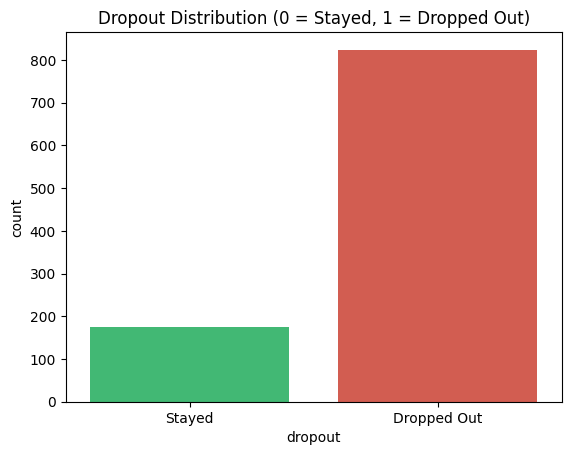

In [4]:
dropout_counts = df['dropout'].value_counts()
print(dropout_counts)
print(f"\nDropout rate: {df['dropout'].mean()*100:.1f}%")

# Visualize
sns.countplot(x='dropout', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Dropout Distribution (0 = Stayed, 1 = Dropped Out)')
plt.xticks([0,1], ['Stayed', 'Dropped Out'])
plt.savefig('../outputs/dropout_distribution.png')
plt.show()

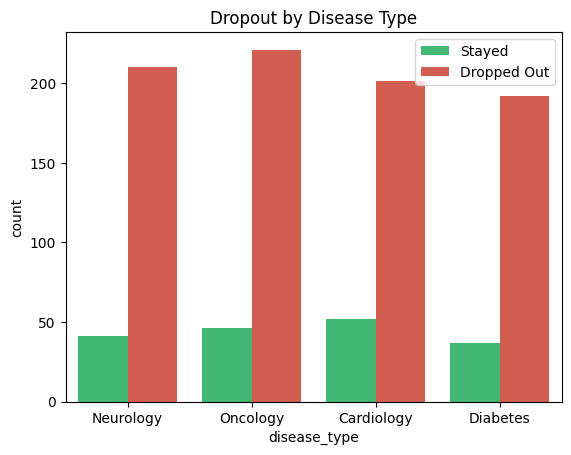

In [5]:
sns.countplot(x='disease_type', hue='dropout', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Dropout by Disease Type')
plt.legend(['Stayed', 'Dropped Out'])
plt.savefig('../outputs/dropout_by_disease.png')
plt.show()

C:\Users\marri\AppData\Local\Temp\ipykernel_12572\1138546696.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dropout', y='site_distance_km', data=df,


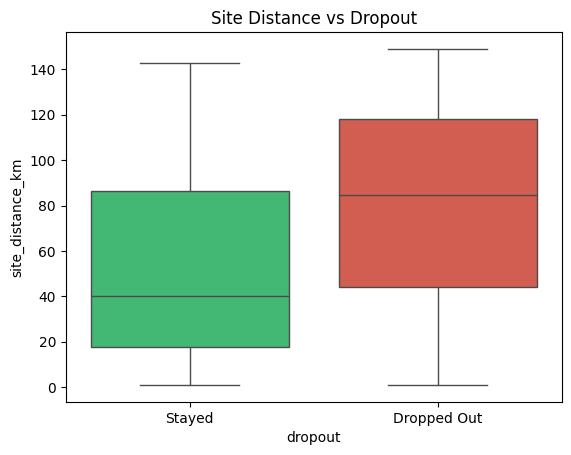

In [6]:
sns.boxplot(x='dropout', y='site_distance_km', data=df,
            palette=['#2ecc71','#e74c3c'])
plt.title('Site Distance vs Dropout')
plt.xticks([0,1], ['Stayed', 'Dropped Out'])
plt.savefig('../outputs/distance_vs_dropout.png')
plt.show()

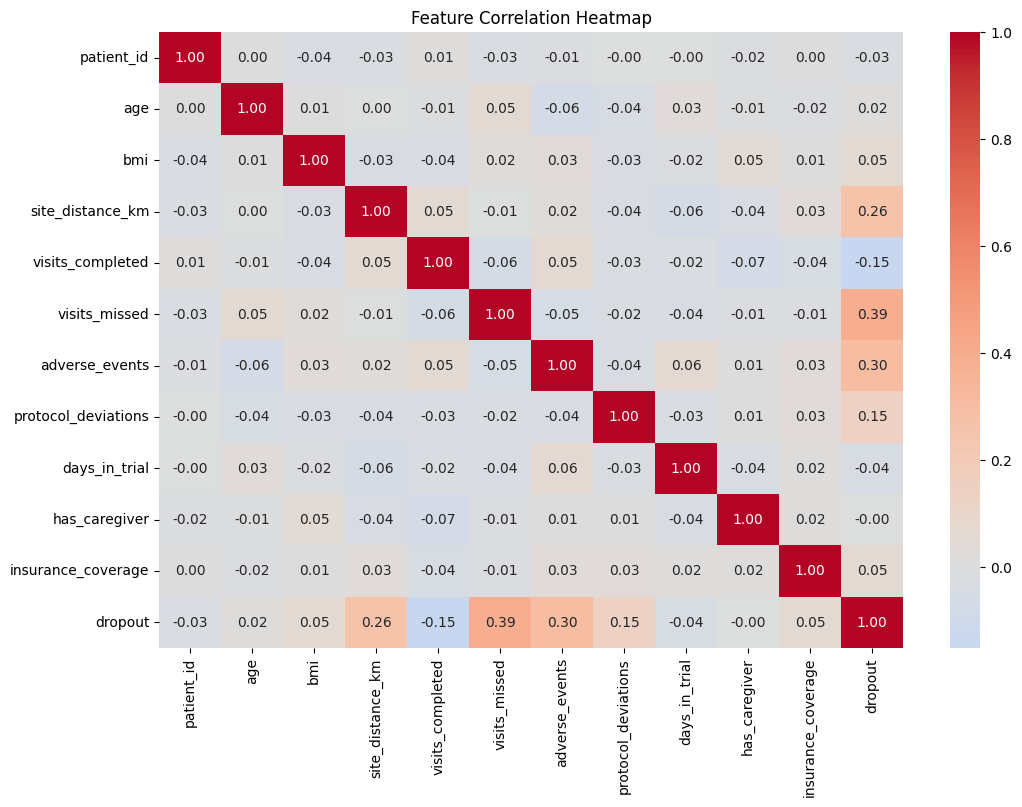

In [7]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()